In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import sys
sys.path.append('../')

from src.neural_net import NeuralNetworkScratch
from src.optimizers import OptimizerEngine


In [2]:
df = pd.read_csv("../data/final_prepared.csv")

scaler = StandardScaler()
X = scaler.fit_transform(df.drop("median_house_value", axis=1))
y = df["median_house_value"].values.reshape(-1, 1)

print("X shape:", X.shape, "y shape:", y.shape)


X shape: (15967, 12) y shape: (15967, 1)


In [3]:
nn = NeuralNetworkScratch(input_size=X.shape[1])
opt = OptimizerEngine(optimizer_type="adam", learning_rate=0.0001, epochs=50)

losses = []
for epoch in range(opt.epochs):
    y_pred, cache = nn.forward(X)
    loss = mean_squared_error(y, y_pred)
    losses.append(loss)

    grads = nn.backward(cache, y)
    nn.W1 = opt.update_params(nn.W1, grads['dW1'], epoch)
    nn.b1 = opt.update_params(nn.b1, grads['db1'], epoch)
    nn.W2 = opt.update_params(nn.W2, grads['dW2'], epoch)
    nn.b2 = opt.update_params(nn.b2, grads['db2'], epoch)
    nn.W3 = opt.update_params(nn.W3, grads['dW3'], epoch)
    nn.b3 = opt.update_params(nn.b3, grads['db3'], epoch)

y_pred_final, _ = nn.forward(X)


In [4]:
mse = mean_squared_error(y, y_pred_final)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_final)

print("NN Evaluation Metrics")
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


NN Evaluation Metrics
MSE: 50275765614.47485
RMSE: 224222.58051872218
R²: -3.469198806330674


In [5]:
lr = LinearRegression()
lr.fit(X, y)
y_pred_lr = lr.predict(X)

mse_lr = mean_squared_error(y, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y, y_pred_lr)

print("Linear Regression Baseline")
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)


Linear Regression Baseline
MSE: 4561414557.153524
RMSE: 67538.24514416646
R²: 0.5945189845474852


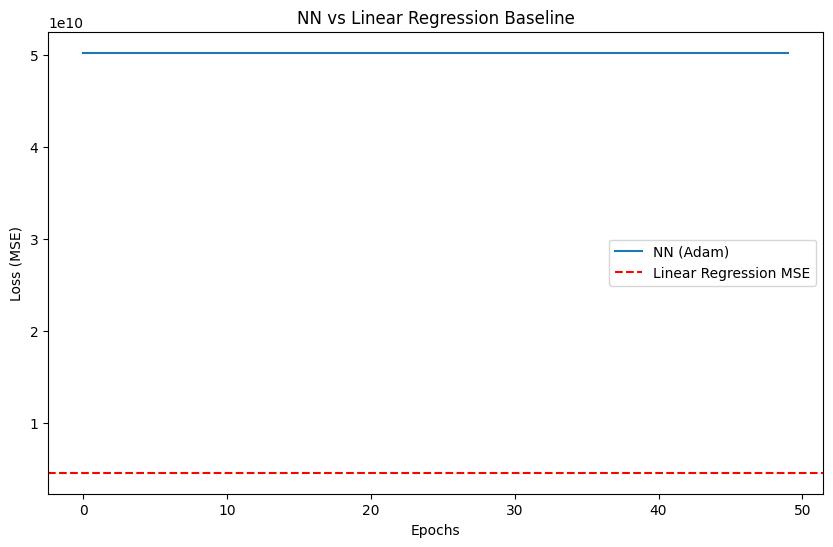

In [6]:
plt.figure(figsize=(10,6))
plt.plot(losses, label="NN (Adam)")
plt.axhline(y=mse_lr, color='r', linestyle='--', label="Linear Regression MSE")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("NN vs Linear Regression Baseline")
plt.legend()
plt.show()


In [8]:
import pickle

# Load optimizer results from Member 3
with open("../data/results_week5.pkl", "rb") as f:
    results = pickle.load(f)

print("Results loaded successfully!")


Results loaded successfully!


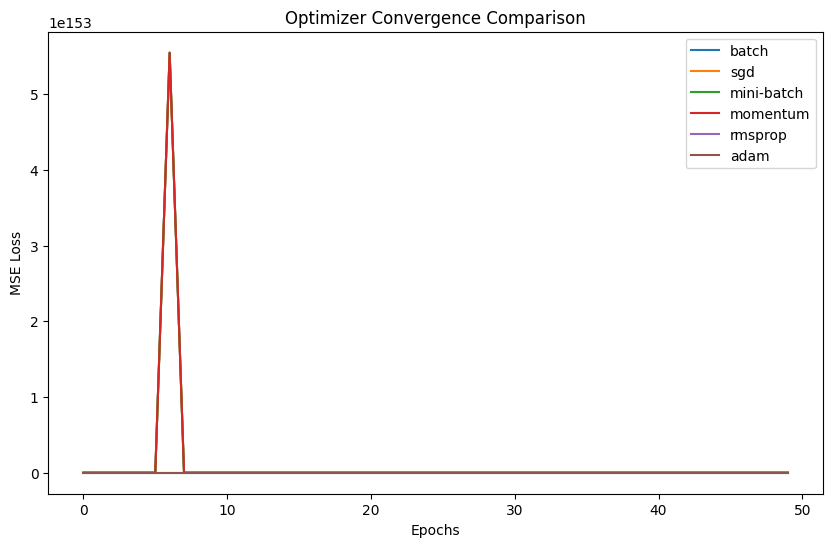

In [9]:
plt.figure(figsize=(10,6))
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Optimizer Convergence Comparison")
plt.legend()
plt.show()
